<a href="https://colab.research.google.com/github/JuliMiralles/Diplomatura-en-An-lisis-Cuantitativo-y-Machine-Learning-aplicado-al-Riesgo-Financiero/blob/main/2_Simulaci%C3%B3n_de_activos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diplomatura en Data Science y Machine Learning para el riesgo financiero

## Modulo 2 - Clase 1: Simulación de Montecarlo y el método Browniano geométrico

En este script aplicaremos los métodos de simulación vistos en clase para diferentes activos, de manera de evaluar las potencialidades y las limitaciones.

## Obtención de datos y análisis exploratorio

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Se define el ticker y la fecha de inicio
ticker = 'AAPL'
start_date = '2022-01-01'

# Obtener datos históricos
data = yf.download(ticker, start=start_date)

# Mostrar las primeras 5 filas de los datos
display(data.head())

/tmp/ipykernel_4140/4172631425.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.786392,178.636214,173.586187,173.703398,104487900
2022-01-04,175.530029,178.694850,174.963487,178.392046,99310400
2022-01-05,170.860931,175.989104,170.587430,175.442101,94537600
2022-01-06,168.008667,171.232092,167.657020,168.692420,96904000
2022-01-07,168.174728,170.099015,167.061183,168.878022,86709100


In [ ]:
# Seleccionar la columna 'Close' del MultiIndex y convertirla a un DataFrame con una sola columna 'Close'
data = data[('Close', ticker)].to_frame(name='Close')
display(data.head())

,Close
Date,
2022-01-03,177.786392
2022-01-04,175.530029
2022-01-05,170.860931
2022-01-06,168.008667
2022-01-07,168.174728


In [ ]:
# Calcula los retornos diarios en escala logarítmica
data['Log_Retorno'] = np.log(data['Close'] / data['Close'].shift(1))

# Calcula la desviación estándar móvil (volatilidad) para ventanas de 20 y 60 días
# Multiplica por sqrt(252) para anualizar la volatilidad (asumiendo 252 días de negociación al año)
data['Rolling_Vol_20D'] = data['Log_Retorno'].rolling(window=20).std() * np.sqrt(252)
data['Rolling_Vol_60D'] = data['Log_Retorno'].rolling(window=60).std() * np.sqrt(252)

# Muestra las primeras filas con las nuevas columnas
display(data.head())

,Close,Log_Retorno,Rolling_Vol_20D,Rolling_Vol_60D
Date,,,,
2022-01-03,177.786392,NaN,NaN,NaN
2022-01-04,175.530029,-0.012773,NaN,NaN
2022-01-05,170.860931,-0.026960,NaN,NaN
2022-01-06,168.008667,-0.016834,NaN,NaN
2022-01-07,168.174728,0.000988,NaN,NaN


In [ ]:
import plotly.graph_objects as go

# Grafica la volatilidad móvil con Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data.index,
    y=data['Rolling_Vol_20D'],
    mode='lines',
    name='Volatilidad Móvil (20-Días)'
))

fig.add_trace(go.Scatter(
    x=data.index,
    y=data['Rolling_Vol_60D'],
    mode='lines',
    name='Volatilidad Móvil (60-Días)'
))

fig.update_layout(
    title=f'Volatilidad Móvil Anualizada de {ticker}',
    xaxis_title='Fecha',
    yaxis_title='Volatilidad',
    hovermode='x unified'
)

fig.show()

## Método Browniano Geométrico (GBM)

El Método Browniano Geométrico (GBM) es un modelo estocástico utilizado para describir la evolución de los precios de las acciones a lo largo del tiempo. Asume que los log-retornos de los activos financieros siguen un paseo aleatorio con una tendencia (drift) y una volatilidad constante.

La fórmula del GBM se expresa generalmente como:

$$S_t = S_{0} \times \exp\left(\left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} Z_t\right)$$


Donde:
- $S_t$: El precio del activo en el tiempo t.
- $S_0$: El precio del activo en el tiempo 0.
- $\mu$: El coeficiente de drift (tendencia) anualizado, que representa el retorno esperado del activo. Es el promedio de los retornos logarítmicos.
- $\sigma$: El coeficiente de volatilidad anualizado, que representa la desviación estándar de los retornos del activo.
- $\Delta t$: El cambio de unidades de tiempo (por ejemplo, 1 día / 252 días de negociación)
- $Z_t$: Una variable aleatoria extraída de una distribución normal estándar.

### Cálculo de los Parámetros para la Simulación del GBM

Para simular el movimiento Browniano Geométrico, necesitamos calcular los siguientes parámetros a partir de los datos históricos de nuestro activo:

1.  **Drift ($\mu$):** El retorno esperado anualizado del activo.
2.  **Volatilidad ($\sigma$):** La volatilidad anualizada del activo.
3.  **Precio Inicial ($S_0$):** El último precio de cierre del activo.

In [ ]:
# Elegimos hasta que fecha considerar para comparar nuestras simulaciones con la realidad
Fecha = '2026-01-01'

# Filtramos el conjunto de datos para el cálculo de los parámetros de simulación
data_filtrada = data[data.index < Fecha]

# Calcula el drift (mu) anualizado
# Se asume 252 días de negociación al año
mu = data_filtrada['Log_Retorno'].mean() * 252

# Calcula la volatilidad (sigma) anualizada
sigma = data_filtrada['Log_Retorno'].std() * np.sqrt(252)

# Obtiene el precio inicial (el último precio de cierre disponible)
S0 = data_filtrada['Close'].iloc[-1]

print(f"Parámetros para la simulación de {ticker}:")
print(f"Drift anualizado (mu): {mu:.4f}")
print(f"Volatilidad anualizada (sigma): {sigma:.4f}")
print(f"Precio inicial (S0): {S0:.2f}")

Parámetros para la simulación de AAPL:
Drift anualizado (mu): 0.1061
Volatilidad anualizada (sigma): 0.2841
Precio inicial (S0): 271.12


### Simulación de Monte Carlo con Método Browniano Geométrico

Con los parámetros calculados (drift, volatilidad y precio inicial), podemos simular múltiples trayectorias futuras del precio de la acción utilizando el Método Browniano Geométrico. Esto nos permite generar una distribución de posibles precios futuros, lo cual es útil para la gestión de riesgos y la valoración de opciones.

In [ ]:
# Definir los parámetros de la simulación
n_simulations = 1000  # Número de simulaciones de Monte Carlo
n_days = 30          # Número de días de trading a simular
dt = 1 / 252       # Paso de tiempo (fracción de un año)

# Crear un array para almacenar los resultados de la simulación
price_paths = np.zeros((n_days, n_simulations))
price_paths[0] = S0

# Realizar la simulación de Monte Carlo
for t in range(1, n_days):
    # Generar números aleatorios de una distribución normal estándar
    Z = np.random.standard_normal(n_simulations)
    # Aplicar la fórmula del Movimiento Browniano Geométrico (versión discreta)
    price_paths[t] = price_paths[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

# Crear un DataFrame para los resultados de la simulación para facilitar la graficación
simulated_prices_df = pd.DataFrame(price_paths, index=pd.date_range(start=Fecha, periods=n_days, freq='B'), columns=[f'Sim_{i+1}' for i in range(n_simulations)])

# Mostrar las primeras filas de las simulaciones
print(f"Primeras 5 filas de los precios simulados para {ticker}:")
display(simulated_prices_df.head())

Primeras 5 filas de los precios simulados para AAPL:


,Sim_1,Sim_2,Sim_3,Sim_4,Sim_5,Sim_6,Sim_7,Sim_8,Sim_9,Sim_10,...,Sim_991,Sim_992,Sim_993,Sim_994,Sim_995,Sim_996,Sim_997,Sim_998,Sim_999,Sim_1000
2026-01-01,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,...,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009
2026-01-02,269.829408,270.376524,271.062666,271.665250,264.089074,270.612382,268.508691,282.040320,265.548223,277.591605,...,274.797370,271.121096,274.355139,271.186447,261.958383,266.816064,261.855265,266.548656,268.556771,272.299469
2026-01-05,264.572940,266.385070,273.982917,273.193559,267.086064,278.893065,273.992630,277.959688,259.523735,280.622545,...,275.046740,268.831018,272.374847,268.309047,259.216442,263.707820,252.519500,273.908162,265.581411,277.144094
2026-01-06,270.095300,277.692755,279.881191,277.906310,264.601589,282.544293,272.701176,284.555766,254.359972,283.977137,...,273.094836,270.401304,263.629251,264.866498,251.939192,265.120124,257.987676,269.847422,263.980771,278.281204
2026-01-07,270.383779,272.902047,278.669673,274.512375,263.265592,275.251240,273.137595,278.682448,250.322154,287.523781,...,273.683802,275.977936,268.870127,256.614451,245.356157,265.076992,261.747031,261.948821,256.040548,276.976526


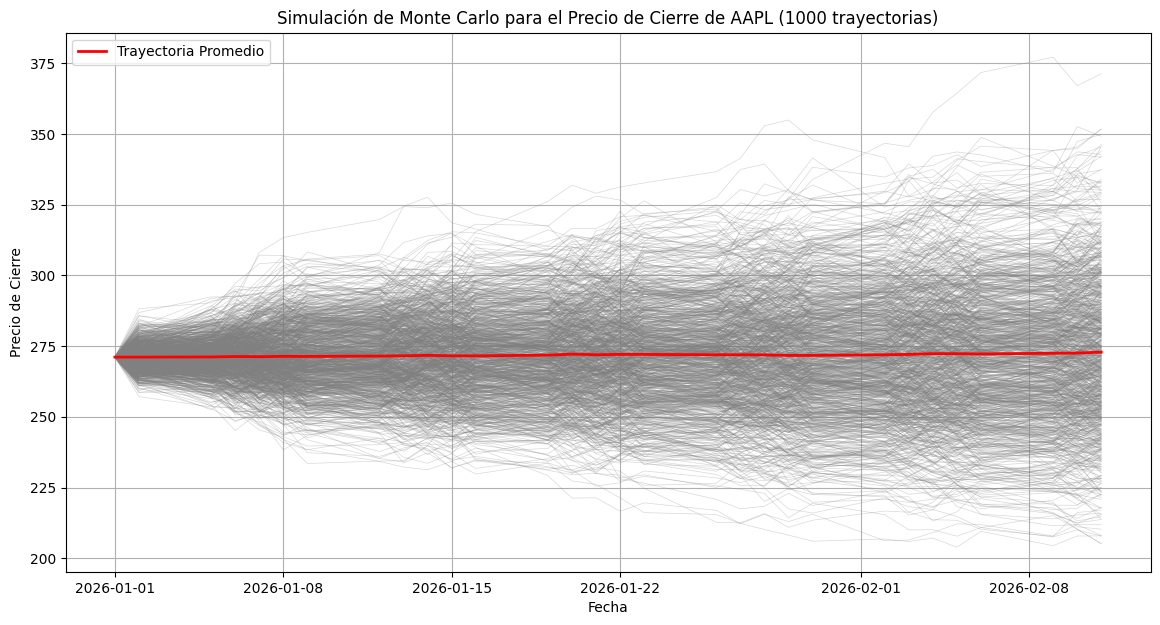

In [ ]:
import matplotlib.pyplot as plt

# Graficar los resultados de la simulación con Matplotlib
plt.figure(figsize=(14, 7))

# Graficar todas las trayectorias individuales
for i in range(n_simulations):
    plt.plot(simulated_prices_df.index, simulated_prices_df[f'Sim_{i+1}'], linewidth=0.5, alpha=0.3, color='gray')

# Calcular y graficar la trayectoria promedio
mean_path = simulated_prices_df.mean(axis=1)
plt.plot(mean_path.index, mean_path, color='red', linewidth=2, label='Trayectoria Promedio')

plt.title(f'Simulación de Monte Carlo para el Precio de Cierre de {ticker} ({n_simulations} trayectorias)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.grid(True)
plt.legend()
plt.show()

## Calculamos las métricas para el activo


In [ ]:
# Definimos el capital invertido en el activo
capital = 100000

# Calculamos el VaR como el valor en el percentil 1 de las simulaciones finales
VaR_99_value = np.percentile(simulated_prices_df.iloc[-1], 1)

# El VaR en porcentaje se calcula como la diferencia porcentual respecto al precio inicial
VaR_99_percentage = abs(((VaR_99_value - S0) / S0) * 100)

# El ES se calcula como el promedio de las pérdidas que exceden el VaR 97,5%
VaR_975_value = np.percentile(simulated_prices_df.iloc[-1], 2.5)
ES_value = np.mean(simulated_prices_df.iloc[-1][simulated_prices_df.iloc[-1] <= VaR_975_value])

# El ES en porcentaje se calcula como la diferencia porcentual respecto al precio inicial
ES_percentage = abs(((ES_value - S0) / S0) * 100)

# Probabilidad de perder valor
prob_perdida = np.mean(simulated_prices_df.iloc[-1] <= S0)

# Mostramos los resultados de la simulación
print(f"Resultados de la simulación a {n_days} días para {ticker} con un capital de {capital} USD:")
print(f"VaR 99%: Porcentaje - {VaR_99_percentage:.2f}%     Valor - {capital*VaR_99_percentage/100:.2f} USD")
print(f"ES: Porcentaje - {ES_percentage:.2f}%      Valor - {capital*ES_percentage/100:.2f} USD")
print(f"Probabilidad de perder valor: {prob_perdida:.4f}")

Resultados de la simulación a 30 días para AAPL con un capital de 100000 USD:
VaR 99%: Porcentaje - 20.57%     Valor - 20568.96 USD
ES: Porcentaje - 20.41%      Valor - 20410.94 USD
Probabilidad de perder valor: 0.4870


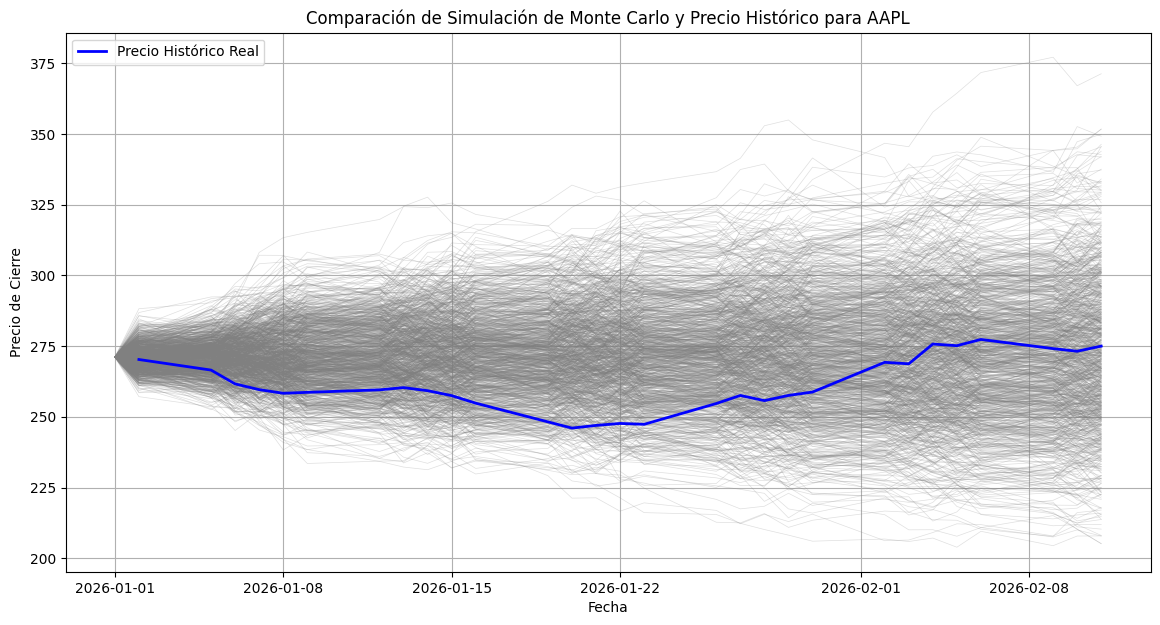

In [ ]:
import matplotlib.pyplot as plt

# Graficar los resultados de la simulación comparados con los datos históricos
plt.figure(figsize=(14, 7))


# Graficar todas las trayectorias individuales simuladas
for i in range(n_simulations):
    plt.plot(simulated_prices_df.index, simulated_prices_df[f'Sim_{i+1}'], linewidth=0.5, alpha=0.25, color='gray')

# Graficar los datos históricos desde la fecha de inicio de la simulación
Ultima_fecha_simulada = simulated_prices_df.index[-1]
historical_data_for_plot = data[(data.index >= Fecha) & (data.index <= Ultima_fecha_simulada)]['Close']
plt.plot(historical_data_for_plot.index, historical_data_for_plot, color='blue', linewidth=2, label='Precio Histórico Real')


plt.title(f'Comparación de Simulación de Monte Carlo y Precio Histórico para {ticker}')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.grid(True)
plt.legend()
plt.show()

## Extensión para portfolio de múltiples activos

En caso de querer simular un portfolio no podemos hacer la simulación de cada activo por separado, sino que tenemos que tener en cuenta la correlación que hay entre nuestros activos.

La fórmula para simular el precio de nuestros activos será la misma que utilizamos antes:


$$S_t = S_{0} \times \exp\left(\left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} Z_t\right)$$


Pero en este caso el $Z_t$ para cada activo no será independiente, sino que utilizará los datos históricos de correlación entre activos a través de lo que se conoce como descomposición de Cholesky.


### Obtención de datos

In [ ]:
# Definir los tickers de los activos para el portfolio
portfolio_tickers = ['AAPL', 'GOOG', 'MSFT']

# Definir la fecha de inicio para obtener los datos históricos
start_date_portfolio = '2022-01-01'

# Obtener datos históricos para cada activo
portfolio_data = yf.download(portfolio_tickers, start=start_date_portfolio)['Close']

# Mostrar las primeras 5 filas de los datos del portfolio
display(portfolio_data.head())

/tmp/ipykernel_4140/4144129112.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOG,MSFT
Date,,,
2022-01-03,177.786346,143.713287,321.856415
2022-01-04,175.530014,143.061462,316.337616
2022-01-05,170.860916,136.361923,304.194092
2022-01-06,168.008682,136.260376,301.790283
2022-01-07,168.174728,135.719009,301.944153


### Definición de los parámetros de la simulación

En esta sección calculamos los parámetros de la simulación que dependen del comportamiento de nuestros activos a lo largo del tiempo.

In [ ]:
# Definimos la fecha en donde vamos a iniciar la simulación
Fecha = '2026-01-01'

# Filtramos el conjunto de datos de precios para el cálculo de los parámetros de simulación del portfolio, usando la fecha de inicio de la simulación.
portfolio_data_for_params = portfolio_data[portfolio_data.index < Fecha]

# Calcular los retornos logarítmicos diarios para cada activo en el período filtrado
log_returns_portfolio = np.log(portfolio_data_for_params / portfolio_data_for_params.shift(1)).dropna()
display(log_returns_portfolio.head())

Ticker,AAPL,GOOG,MSFT
Date,,,
2022-01-04,-0.012772,-0.004546,-0.017295
2022-01-05,-0.026960,-0.047962,-0.039144
2022-01-06,-0.016834,-0.000745,-0.007934
2022-01-07,0.000988,-0.003981,0.000510
2022-01-10,0.000116,0.011391,0.000732


In [ ]:
# Calcular la matriz de covarianza anualizada de los retornos logarítmicos
cov_matrix = log_returns_portfolio.cov() * 252
display(cov_matrix)

Ticker,AAPL,GOOG,MSFT
Ticker,,,
AAPL,0.080696,0.053995,0.047563
GOOG,0.053995,0.105873,0.055137
MSFT,0.047563,0.055137,0.071434


In [ ]:
# Calcular la descomposición de Cholesky de la matriz de covarianza
chol_matrix = np.linalg.cholesky(cov_matrix)
display(chol_matrix)

array([[0.28407062, 0.        , 0.        ],
       [0.19007546, 0.26409105, 0.        ],
       [0.16743536, 0.08827117, 0.18869864]])

In [ ]:
# Calcular el drift (mu) y la volatilidad (sigma) anualizados para cada activo
mu_portfolio = log_returns_portfolio.mean() * 252
sigma_portfolio = log_returns_portfolio.std() * np.sqrt(252)

# Obtener los precios iniciales (el último precio de cierre disponible antes de la fecha de simulación)
S0_portfolio = portfolio_data_for_params.iloc[-1]

print("Parámetros para la simulación del portfolio:")
print(f"Drift anualizado (mu):\n{mu_portfolio.round(4)}")
print(f"Volatilidad anualizada (sigma):\n{sigma_portfolio.round(4)}")
print(f"Precios iniciales (S0):\n{S0_portfolio.round(2)}")

Parámetros para la simulación del portfolio:
Drift anualizado (mu):
Ticker
AAPL    0.1061
GOOG    0.1959
MSFT    0.1008
dtype: float64
Volatilidad anualizada (sigma):
Ticker
AAPL    0.2841
GOOG    0.3254
MSFT    0.2673
dtype: float64
Precios iniciales (S0):
Ticker
AAPL    271.12
GOOG    313.19
MSFT    480.57
Name: 2025-12-31 00:00:00, dtype: float64


In [ ]:
# Definir los pesos para cada activo en el portfolio
# Asegúrate de que la suma de los pesos sea igual a 1
portfolio_weights = np.array([0.4, 0.3, 0.3]) # Ejemplo: 40% AAPL, 30% GOOG, 30% MSFT

# Verificar que la suma de los pesos sea 1
if not np.isclose(np.sum(portfolio_weights), 1.0):
    raise ValueError("La suma de los pesos del portfolio debe ser 1.")

print(f"Pesos del portfolio: {portfolio_weights}")

Pesos del portfolio: [0.4 0.3 0.3]


### Simulación

In [ ]:
# Definir los parámetros de la simulación
n_simulations_portfolio = 1000  # Número de simulaciones de Monte Carlo
n_days_portfolio = 30         # Número de días de trading a simular
dt_portfolio = 1 / 252      # Paso de tiempo (fracción de un año)

# Crear un array para almacenar los resultados de la simulación
# Dimensiones: (días, simulaciones, activos)
price_paths_portfolio = np.zeros((n_days_portfolio, n_simulations_portfolio, len(portfolio_tickers)))

# Inicializar con los precios iniciales para cada activo
price_paths_portfolio[0, :, :] = S0_portfolio.values

# Realizar la simulación de Monte Carlo con Cholesky
for t in range(1, n_days_portfolio):
    # Generar números aleatorios correlacionados
    Z_uncorrelated = np.random.standard_normal((n_simulations_portfolio, len(portfolio_tickers)))
    Z_correlated = Z_uncorrelated @ chol_matrix.T

    # Aplicar la fórmula del Movimiento Browniano Geométrico para cada activo
    drift_term = (mu_portfolio.values - 0.5 * sigma_portfolio.values**2) * dt_portfolio
    volatility_term = sigma_portfolio.values * np.sqrt(dt_portfolio) * Z_correlated

    price_paths_portfolio[t, :, :] = price_paths_portfolio[t-1, :, :] * np.exp(drift_term + volatility_term)

# Crear un DataFrame para los resultados de la simulación para realizar el gráfico
simulated_portfolio_prices_dfs = {}
for i, ticker_name in enumerate(portfolio_tickers):
    df_temp = pd.DataFrame(
        price_paths_portfolio[:, :, i],
        index=pd.date_range(start=Fecha, periods=n_days_portfolio, freq='B'),
        columns=[f'{ticker_name}_Sim_{j+1}' for j in range(n_simulations_portfolio)]
    )
    simulated_portfolio_prices_dfs[ticker_name] = df_temp

# Mostrar las primeras filas de las simulaciones para AAPL como ejemplo
print(f"Primeras 5 filas de los precios simulados para AAPL en el portfolio:")
display(simulated_portfolio_prices_dfs['AAPL'].head())

Primeras 5 filas de los precios simulados para AAPL en el portfolio:


,AAPL_Sim_1,AAPL_Sim_2,AAPL_Sim_3,AAPL_Sim_4,AAPL_Sim_5,AAPL_Sim_6,AAPL_Sim_7,AAPL_Sim_8,AAPL_Sim_9,AAPL_Sim_10,...,AAPL_Sim_991,AAPL_Sim_992,AAPL_Sim_993,AAPL_Sim_994,AAPL_Sim_995,AAPL_Sim_996,AAPL_Sim_997,AAPL_Sim_998,AAPL_Sim_999,AAPL_Sim_1000
2026-01-01,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,...,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009,271.122009
2026-01-02,273.519668,272.085759,272.939069,270.398878,270.003498,271.158921,270.463774,272.177932,270.800887,273.034808,...,273.808817,271.142638,269.758746,271.677038,270.839916,271.746144,270.186513,270.289252,269.513784,268.845747
2026-01-05,275.803348,271.611066,274.672995,270.562098,270.233605,272.980335,269.184293,274.052458,270.892137,274.739506,...,273.531044,272.689486,268.744034,273.721580,270.846095,272.391696,269.798941,271.069554,269.303563,268.628372
2026-01-06,277.796471,271.299008,272.965025,271.790456,272.242595,275.230443,268.522235,274.420121,272.967901,276.666502,...,274.472838,272.903807,270.459593,275.063950,270.305259,272.716018,268.513352,272.522299,272.085892,268.695044
2026-01-07,277.471828,269.972508,270.907519,271.371853,273.738554,273.655754,269.474214,271.649218,275.589066,276.948099,...,274.270230,271.206347,269.874032,275.125454,269.073448,275.143229,269.678006,271.469662,272.237168,269.842545


In [ ]:
# Calcular el valor inicial del portfolio
initial_portfolio_value = np.sum(S0_portfolio.values * portfolio_weights)

# Calcular las trayectorias de valor del portfolio a partir de los precios simulados de los activos
# Multiplicamos los precios simulados de cada activo por su peso y sumamos a través de los activos
portfolio_value_paths = np.sum(price_paths_portfolio * portfolio_weights, axis=2)

# Crear un DataFrame para los resultados de la simulación del valor del portfolio
simulated_portfolio_value_df = pd.DataFrame(
    portfolio_value_paths,
    index=pd.date_range(start=Fecha, periods=n_days_portfolio, freq='B'),
    columns=[f'Portfolio_Sim_{j+1}' for j in range(n_simulations_portfolio)]
)

print(f"Valor inicial del portfolio: {initial_portfolio_value:.2f}")
print(f"Primeras 5 filas del valor simulado del portfolio:")
display(simulated_portfolio_value_df.head())

Valor inicial del portfolio: 346.58
Primeras 5 filas del valor simulado del portfolio:


,Portfolio_Sim_1,Portfolio_Sim_2,Portfolio_Sim_3,Portfolio_Sim_4,Portfolio_Sim_5,Portfolio_Sim_6,Portfolio_Sim_7,Portfolio_Sim_8,Portfolio_Sim_9,Portfolio_Sim_10,...,Portfolio_Sim_991,Portfolio_Sim_992,Portfolio_Sim_993,Portfolio_Sim_994,Portfolio_Sim_995,Portfolio_Sim_996,Portfolio_Sim_997,Portfolio_Sim_998,Portfolio_Sim_999,Portfolio_Sim_1000
2026-01-01,346.576303,346.576303,346.576303,346.576303,346.576303,346.576303,346.576303,346.576303,346.576303,346.576303,...,346.576303,346.576303,346.576303,346.576303,346.576303,346.576303,346.576303,346.576303,346.576303,346.576303
2026-01-02,347.739293,348.124123,348.396639,346.051001,345.486370,346.718165,346.458699,349.222090,345.488522,348.908073,...,349.464791,347.183454,345.425809,345.354664,346.503151,346.343722,346.004900,345.281049,345.740437,345.453351
2026-01-05,350.488312,347.482056,349.245452,346.688275,345.288603,348.325710,343.272378,350.880569,345.139652,349.493730,...,349.587510,349.359621,343.368541,348.892269,345.646500,346.305229,345.218707,346.446334,344.590663,345.531426
2026-01-06,353.292868,347.278212,347.655253,346.769030,347.397259,349.753472,341.986945,352.082024,345.180418,351.887283,...,350.039967,348.900795,345.489630,351.049395,345.802048,346.496696,344.097078,347.511125,348.101027,345.211080
2026-01-07,353.553358,346.251127,346.568175,346.865670,350.196232,347.629710,342.191553,349.289923,347.853476,352.890012,...,347.800634,347.579110,344.270052,350.770493,344.424873,349.692452,345.410774,346.762526,348.372508,347.855369


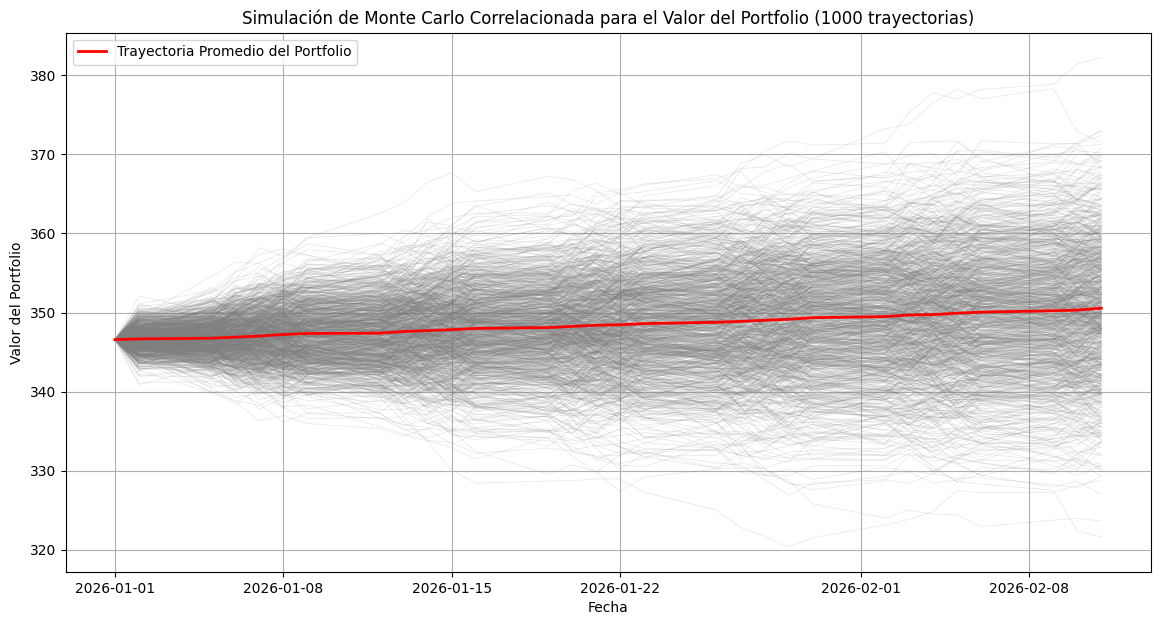

In [ ]:
# Graficar los resultados de la simulación para el valor total del portfolio
plt.figure(figsize=(14, 7))

# Graficar todas las trayectorias individuales del portfolio
for i in range(n_simulations_portfolio):
    plt.plot(simulated_portfolio_value_df.index, simulated_portfolio_value_df[f'Portfolio_Sim_{i+1}'], linewidth=0.5, alpha=0.2, color='gray')

# Calcular y graficar la trayectoria promedio del portfolio
mean_portfolio_path = simulated_portfolio_value_df.mean(axis=1)
plt.plot(mean_portfolio_path.index, mean_portfolio_path, color='red', linewidth=2, label='Trayectoria Promedio del Portfolio')

plt.title(f'Simulación de Monte Carlo Correlacionada para el Valor del Portfolio ({n_simulations_portfolio} trayectorias)')
plt.xlabel('Fecha')
plt.ylabel('Valor del Portfolio')
plt.grid(True)
plt.legend()
plt.show()

### Métricas del portfolio

In [ ]:
# Calcular métricas de riesgo para el portfolio
# Primero definimos el capital
capital = 100000

# Valor del percentil 1 del portfolio
VaR_99_portfolio_value = np.percentile(simulated_portfolio_value_df.iloc[-1], 1)

# VaR 99% del Portfolio en porcentaje
VaR_99_portfolio_percentage = abs(((VaR_99_portfolio_value - initial_portfolio_value) / initial_portfolio_value) * 100)

# ES del Portfolio en porcentaje
# Valor del percentil 1 del portfolio
VaR_975_portfolio_value = np.percentile(simulated_portfolio_value_df.iloc[-1], 2.5)

ES_portfolio_value = np.mean(simulated_portfolio_value_df.iloc[-1][simulated_portfolio_value_df.iloc[-1] <= VaR_975_portfolio_value])
ES_portfolio_percentage = abs(((ES_portfolio_value - initial_portfolio_value) / initial_portfolio_value) * 100)

# Probabilidad de perder valor en el Portfolio
prob_perdida_portfolio = np.mean(simulated_portfolio_value_df.iloc[-1] <= initial_portfolio_value)

# Mostrar los resultados de la simulación para el Portfolio
print(f"Resultados de la simulación a {n_days_portfolio} días para el Portfolio, con un capital de {capital} USD:")
print(f"VaR 99% del Portfolio: Porcentaje - {VaR_99_portfolio_percentage:.2f}%        Valor - {capital*VaR_99_portfolio_percentage/100:.2f} USD")
print(f"ES del Portfolio: Porcentaje - {ES_portfolio_percentage:.2f}%         Valor - {capital*ES_portfolio_percentage/100:.2f} USD")
print(f"Probabilidad de perder valor en el Portfolio: {prob_perdida_portfolio:.4f}")

Resultados de la simulación a 30 días para el Portfolio, con un capital de 100000 USD:
VaR 99% del Portfolio: Porcentaje - 4.60%        Valor - 4599.22 USD
ES del Portfolio: Porcentaje - 4.50%         Valor - 4504.41 USD
Probabilidad de perder valor en el Portfolio: 0.3040


## Actividad para los alumnos: Simulación de Portfolio y Métricas de Riesgo

**Objetivo:** Aplicar los conocimientos adquiridos para simular un nuevo portfolio y calcular sus métricas de riesgo.

**Instrucciones:**

1.  **Define tu propio portfolio:** Elige al menos 3 tickers de tu interés y asigna pesos a cada uno. Asegúrate de que la suma de los pesos sea igual a 1.
2.  **Configura la simulación:** Define el capital inicial para tu inversión y el n_days (número de días) para la simulación.
3.  **Calcula los parámetros:** Utiliza el código proporcionado anteriormente para calcular los parámetros necesarios (drift, volatilidad, matriz de covarianza y descomposición de Cholesky) para tu portfolio.
4.  **Realiza la simulación:** Simula las trayectorias de precios para cada activo y calcula el valor del portfolio a lo largo del tiempo.
5.  **Calcula VaR y ES:** Determina el VaR (Value at Risk) al 99% y el ES (Expected Shortfall) para tu portfolio.
6.  **Interpreta tus resultados:** ¿Qué significan estos valores para tu portfolio?

In [ ]:
# --- Comienza tu actividad aquí ---
